# 03 - Exploratory Data Analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/air_quality_cleaned.csv")
print(df.shape)

(3093, 10)


In [5]:
df.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3093.000000,3093.000000,3093.000000,3093.000000,3093.000000
mean,22.816847,78.432803,38.447462,110.112512,66.345942
std,5.422462,4.764939,52.989872,121.596988,82.902002
min,8.514909,70.909168,1.000000,1.000000,1.000000
25%,19.090337,75.389600,6.000000,21.000000,11.000000
50%,23.264759,77.278761,18.000000,69.000000,33.000000
75%,27.215415,80.249612,51.000000,140.000000,88.000000
max,34.066206,94.636574,360.000000,500.000000,436.000000


In [6]:
# average pollutant values per pollutant type
df.groupby("pollutant_id")["pollutant_avg"].mean().round(2)

pollutant_id
CO        51.78
NH3        7.11
NO2       36.75
OZONE     18.67
PM10     151.78
PM2.5    175.23
SO2       17.75
Name: pollutant_avg, dtype: float64

In [7]:
# PM2.5 and PM10 subsets
pm25 = df[df["pollutant_id"] == "PM2.5"]
pm10 = df[df["pollutant_id"] == "PM10"]

print("PM2.5 rows:", len(pm25))
print("PM10  rows:", len(pm10))

PM2.5 rows: 447
PM10  rows: 444


In [8]:
# top 10 states by mean PM2.5
state_pm25 = pm25.groupby("state")["pollutant_avg"].mean().sort_values(ascending=False)
print(state_pm25.head(10))

state
Delhi               358.540541
Chandigarh          322.333333
Bihar               290.111111
Tripura             289.000000
Himachal Pradesh    262.000000
Odisha              225.722222
West Bengal         219.800000
Uttar Pradesh       198.020000
Rajasthan           193.976190
Haryana             187.285714
Name: pollutant_avg, dtype: float64


In [9]:
# top 10 cities by mean PM2.5
city_pm25 = pm25.groupby("city")["pollutant_avg"].mean().sort_values(ascending=False)
print(city_pm25.head(10))

city
Sri Ganganagar    406.000000
Bhagalpur         400.500000
Rajgir            359.000000
Delhi             358.540541
Chhapra           354.000000
Karauli           351.000000
Greater Noida     346.000000
Purnia            346.000000
Hanumangarh       340.000000
Bihar Sharif      333.000000
Name: pollutant_avg, dtype: float64


In [10]:
# how many PM2.5 readings are above 90 (Poor category)
above_90 = pm25[pm25["pollutant_avg"] > 90]
print("Readings above 90 :", len(above_90))
pct = len(above_90) / len(pm25) * 100
print("Percentage        : {:.1f}%".format(pct))

Readings above 90 : 328
Percentage        : 73.4%


In [12]:
# worst 5 stations by PM2.5
worst = pm25.sort_values("pollutant_avg", ascending=False)
worst[["state", "city", "station", "pollutant_avg"]].head(5)

,state,city,station,pollutant_avg
2507,Bihar,Bhagalpur,"DM Office_Kachari Chowk, Bhagalpur - BSPCB",410.0
1933,Delhi,Delhi,"Nehru Nagar, Delhi - DPCC",406.0
438,Rajasthan,Sri Ganganagar,"Old City, Sri Ganganagar - RSPCB",406.0
101,Delhi,Delhi,"Jahangirpuri, Delhi - DPCC",404.0
2525,Bihar,Patna,"DRM Office Danapur, Patna - BSPCB",401.0


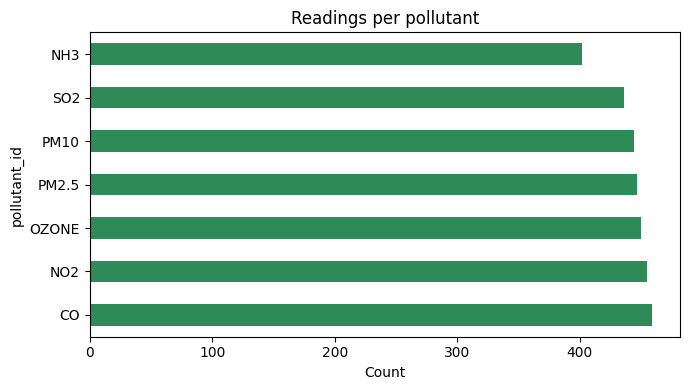

In [13]:
# number of readings per pollutant
plt.figure(figsize=(7, 4))
df["pollutant_id"].value_counts().plot(kind="barh", color="seagreen")
plt.title("Readings per pollutant")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/01_pollutant_counts.png", dpi=150)
plt.show()

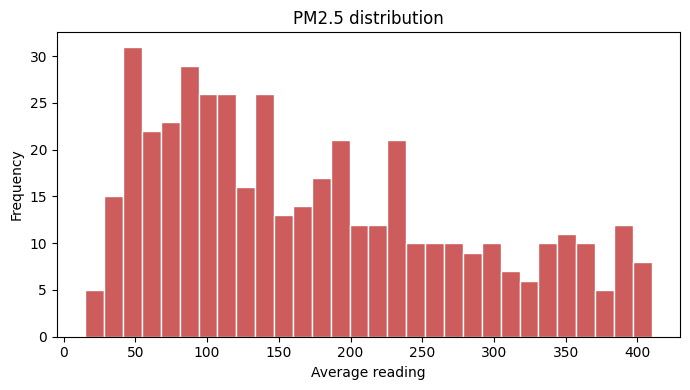

In [14]:
# PM2.5 histogram
plt.figure(figsize=(7, 4))
plt.hist(pm25["pollutant_avg"].dropna(), bins=30, color="indianred", edgecolor="white")
plt.title("PM2.5 distribution")
plt.xlabel("Average reading")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../outputs/figures/02_pm25_histogram.png", dpi=150)
plt.show()

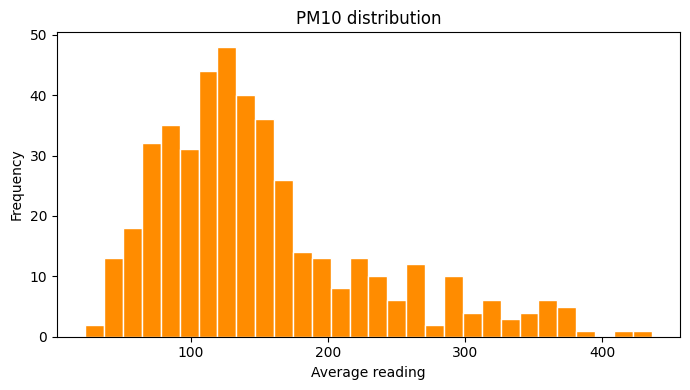

In [15]:
# PM10 histogram
plt.figure(figsize=(7, 4))
plt.hist(pm10["pollutant_avg"].dropna(), bins=30, color="darkorange", edgecolor="white")
plt.title("PM10 distribution")
plt.xlabel("Average reading")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../outputs/figures/03_pm10_histogram.png", dpi=150)
plt.show()

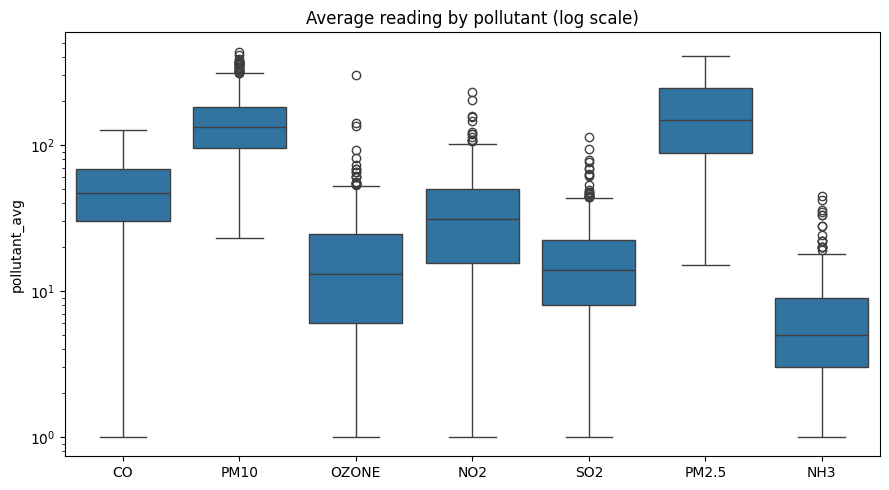

In [16]:
# boxplot of all pollutants
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="pollutant_id", y="pollutant_avg")
plt.yscale("log")
plt.title("Average reading by pollutant (log scale)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("../outputs/figures/04_pollutant_boxplot.png", dpi=150)
plt.show()